In [1]:
import pandas as pd


In [2]:
df=pd.read_csv(r'C:\Users\Check-in\Downloads\house_prices.csv')  
#df.head()

In [ ]:
df.shape 


In [ ]:
df.describe()

In [ ]:
df.info()

In [ ]:
df.isna().sum()

In [ ]:
df.isna().mean().sort_values(ascending=False)

preprocessing

Amount(in rupees)

In [4]:
def parse_amount(x):
   if not isinstance(x, str):
        return None
   x = x.strip().lower()
   try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
   except ValueError:
        return None
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount) 
df = df.dropna(subset=["price_clean"])

In [319]:
# Convert area values to square feet
def convert_area_to_sqft(x):
    if pd.isna(x):
        return np.nan

    x = str(x).lower().strip().replace(",", "")

    # Extract numeric value
    match = re.search(r"[\d.]+", x)

    if not match:
        return np.nan

    value = float(match.group())

    # Square meter -> square feet
    if "sqm" in x or "sq m" in x or "m²" in x or "m2" in x:
        return value * 10.764

    # Square feet
    if "sqft" in x or "sq ft" in x or "square feet" in x:
        return value

    # If unit is missing, keep the numeric value
    return value


# Apply to area columns
for col in ["Carpet Area", "Super Area", "Plot Area"]:
    df[col + "_sqft"] = df[col].apply(convert_area_to_sqft)

print(
    df[
        [
            "Carpet Area", "Carpet Area_sqft",
            "Super Area", "Super Area_sqft",
            "Plot Area", "Plot Area_sqft"
        ]
    ].head(3)
)

  Carpet Area  Carpet Area_sqft Super Area  Super Area_sqft  Plot Area  \
0    500 sqft             500.0        NaN              NaN        NaN   
1    473 sqft             473.0        NaN              NaN        NaN   
2    779 sqft             779.0        NaN              NaN        NaN   

   Plot Area_sqft  
0             NaN  
1             NaN  
2             NaN  


In [320]:
df['Area'] = df[
    ['Carpet Area_sqft', 'Super Area_sqft', 'Plot Area_sqft']
].bfill(axis=1).iloc[:, 0]

In [321]:
df.drop(columns=['Carpet Area', 'Carpet Area_sqft', 'Super Area', 'Super Area_sqft','Plot Area','Plot Area_sqft'], inplace=True)  

Floor

In [322]:
def extract_floor(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()

    # Ground floor
    if "ground" in x:
        return 0

    # Basement
    if "basement" in x:
        return -1

    # Handle "3 out of 10"
    match = re.search(r"(-?\d+)\s*out\s*of", x)
    if match:
        return float(match.group(1))

    # Handle values such as "1st", "2nd", "3rd", "10th"
    match = re.search(r"-?\d+", x)
    if match:
        return float(match.group())

    return np.nan


df["floor_number"] = df["Floor"].apply(extract_floor)

print(df[["Floor", "floor_number"]].head(20))

              Floor  floor_number
0      10 out of 11          10.0
1       3 out of 22           3.0
2      10 out of 29          10.0
3        1 out of 3           1.0
4      20 out of 42          20.0
5        2 out of 7           2.0
6        4 out of 5           4.0
7   Ground out of 7           0.0
8   Ground out of 2           0.0
9       3 out of 27           3.0
10      6 out of 20           6.0
11     16 out of 24          16.0
12      8 out of 20           8.0
13     18 out of 27          18.0
14       2 out of 3           2.0
15     10 out of 16          10.0
16       5 out of 7           5.0
17       4 out of 5           4.0
18     20 out of 28          20.0
19       3 out of 3           3.0


Bathroom / Balcony / Car Parking → numeric

In [323]:
def extract_numeric(x):
    if pd.isna(x):
        return np.nan

    match = re.search(r"\d+(?:\.\d+)?", str(x))

    if match:
        return float(match.group())

    return np.nan


# Convert to numeric
for col in ["Bathroom", "Balcony", "Car Parking"]:
    df[col + "_num"] = df[col].apply(extract_numeric)

# Fill missing values with median
for col in ["Bathroom_num", "Balcony_num", "Car Parking_num"]:
    median_value = df[col].median()

    # If median itself is missing, use 0
    if pd.isna(median_value):
        median_value = 0

    df[col] = df[col].fillna(median_value)

print(
    df[
        [
            "Bathroom", "Bathroom_num",
            "Balcony", "Balcony_num",
            "Car Parking", "Car Parking_num"
        ]
    ].head(10)
)

  Bathroom  Bathroom_num Balcony  Balcony_num Car Parking  Car Parking_num
0        1           1.0       2          2.0         NaN              1.0
1        2           2.0     NaN          2.0      1 Open              1.0
2        2           2.0     NaN          2.0   1 Covered              1.0
3        1           1.0       1          1.0         NaN              1.0
4        2           2.0     NaN          2.0   1 Covered              1.0
5        1           1.0       1          1.0         NaN              1.0
6        1           1.0     NaN          2.0         NaN              1.0
7        1           1.0     NaN          2.0         NaN              1.0
8        1           1.0     NaN          2.0         NaN              1.0
9        3           3.0       1          1.0   1 Covered              1.0


High-cardinality categoricals

In [324]:
TOP_N = 50

for col in ["location", "Society"]:
    # Keep the 50 most frequent categories
    top_categories = df[col].value_counts().nlargest(TOP_N).index

    df[col] = df[col].where(
        df[col].isin(top_categories),
        "Other"
    )

# One-hot encode categorical columns
# categorical_cols = [
    
   
#     "facing",
#     "overlooking",
#     "locations",
#     "Society"

# ]

# # Only use columns that actually exist
# categorical_cols = [col for col in categorical_cols if col in df.columns]

# df = pd.get_dummies(
#     df,
#     columns=categorical_cols,
#     drop_first=True
# )

# print("Shape after one-hot encoding:", df.shape)

Drop useless columns

In [325]:
# Columns that are not useful for prediction
useless_columns = [
    "Index",
    "Title",
    "Description",
    "Dimensions",
  
]

# Drop only columns that exist
useless_columns = [
    col for col in useless_columns
    if col in df.columns
]

df = df.drop(columns=useless_columns)

# Drop columns that are more than 80% missing
missing_threshold = 0.80

mostly_empty_cols = [
    col for col in df.columns
    if df[col].isna().mean() > missing_threshold
]

df = df.drop(columns=mostly_empty_cols)

print("Dropped useless columns:", useless_columns)
print("Dropped mostly-empty columns:", mostly_empty_cols)
print("Remaining shape:", df.shape)

Dropped useless columns: ['Index', 'Title', 'Description', 'Dimensions']
Dropped mostly-empty columns: []
Remaining shape: (177847, 20)


EDA

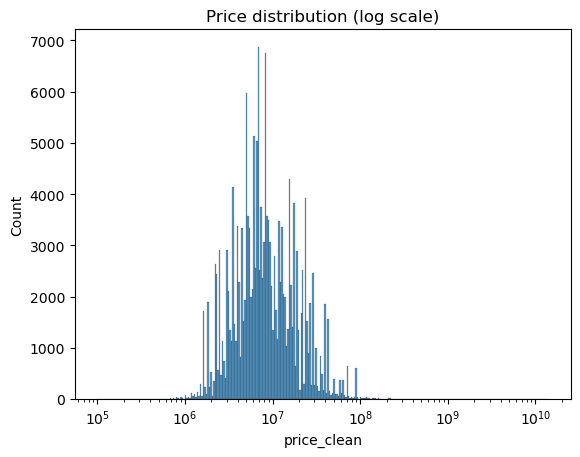

In [5]:
import matplotlib.pyplot as plt 
import seaborn as sns
sns.histplot(df["price_clean"], log_scale=True) 
plt.title("Price distribution (log scale)") 
plt.show()

In [ ]:
import re
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

def parse_area_sqft(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip().lower().replace(",", "")
    match = re.search(r"[\d.]+", s)
    if not match:
        return np.nan

    value = float(match.group())

    if "sqm" in s or "sq m" in s or "m²" in s or "m2" in s:
        value *= 10.764

    return value

plot_df = pd.DataFrame({
    "Carpet Area_sqft": df["Carpet Area"].apply(parse_area_sqft),
    "price_clean": df["price_clean"]
}).dropna()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x="Carpet Area_sqft",
    y="price_clean",
    alpha=0.5
)
plt.title("Price vs. Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (₹)")
plt.tight_layout()
plt.show()

In [ ]:
df.dropna(subset=['floor_number', 'Area','facing','overlooking','Transaction', 'Furnishing'], inplace=True)

   


pipline

In [333]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor

numeric_features = [
    "Area",
    "floor_number",
    "Bathroom_num",
    "Balcony_num"
]

categorical_features = [
    "location",
    "overlooking",
    "facing"
]

ordinal_features = [
    "Furnishing",
    "Transaction"
]

preprocessor = ColumnTransformer([
    
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),

    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features),

    ("ord", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(
            categories=[
                ["Unfurnished", "Semi-Furnished", "Furnished"],
                ["New Property", "Resale"]
            ],
            handle_unknown="use_encoded_value",
            unknown_value=-1
        ))
    ]), ordinal_features)
])

X = df[numeric_features + categorical_features + ordinal_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['Area', 'floor_number',
                                                   'Bathroom_num',
                                                   'Balcony_num']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['location', 'overl...
                                                   'facing']),
                                                 ('ord',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['Unfurnished',
                                                                                               'Semi-Furnished',
                                                                                               'Furnished'],
                                                                                              ['New '
                                                                                               'Property',
                                                                                               'Resale']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Furnishing',
                                                   'Transaction'])])),
                ('reg',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [336]:
from sklearn.metrics import mean_absolute_error,  r2_score
pred = model.predict(X_test)
print("MAE :", mean_absolute_error(y_test, pred)) 
print("RMSE:", mean_absolute_error(y_test, pred) ** 0.5) 
print("R² :", r2_score(y_test, pred))

MAE : 1482506.0590972926
RMSE: 1217.5820543590862
R² : 0.24447098503981768


In [337]:
import joblib
joblib.dump(model, "house_price.pkl")
# Sanity check: reload and predict one sample 
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", loaded.predict(sample))

Reloaded prediction: [12114450.]


In [339]:
import os

print(os.getcwd())

c:\Users\Check-in\AppData\Local\Programs\Microsoft VS Code


In [340]:
import os
import shutil

# مكان مشروع الـ Backend
project_dir = r"C:\Users\Check-in\Downloads\house_price_project"

# إنشاء الفولدر
os.makedirs(project_dir, exist_ok=True)

# نقل نسخة من الموديل إلى المشروع
shutil.copy(
    "house_price.pkl",
    os.path.join(project_dir, "house_price.pkl")
)

print("Project folder:", project_dir)
print("Model:", os.path.join(project_dir, "house_price.pkl"))

Project folder: C:\Users\Check-in\Downloads\house_price_project
Model: C:\Users\Check-in\Downloads\house_price_project\house_price.pkl
